In [13]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

import healpy as hp

In [14]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [74]:
target_densities_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/lrg_xcorr/density_maps/1.0.0/resolve/v1.0'
randoms_counts_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_sys/randoms_stats/0.49.0/resolve/counts'

min_nobs = 2
maskbits = [1, 8, 9, 11, 12, 13]
nside = 64
min_pix_frac = 0.2  # minimum fraction of pixel area to be used

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print(nside, 'Healpix size = {:.5f} sq deg'.format(pix_area))

bin_index = 4
field = 'combined'
density_north = Table.read(os.path.join(target_densities_dir, 'density_map_lrg_pz_bin_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(bin_index, 'north', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
density_south = Table.read(os.path.join(target_densities_dir, 'density_map_lrg_pz_bin_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(bin_index, 'south', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))

mask = (density_north['DEC']>32.375)
density_north = density_north[mask]
mask = ~np.in1d(density_south['HPXPIXEL'], density_north['HPXPIXEL'])
density = vstack([density_north, density_south[mask]])

maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format('north', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
maps = maps[maps['n_randoms']>0]
maps_north = maps.copy()

maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format('south', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
maps = maps[maps['n_randoms']>0]
maps_south = maps.copy()

mask = (maps_north['DEC']>32.375)
maps_north = maps_north[mask]
mask = ~np.in1d(maps_south['HPXPIXEL'], maps_north['HPXPIXEL'])
maps = vstack([maps_north, maps_south[mask]])

maps = join(maps, density[['HPXPIXEL', 'n_targets']], join_type='outer', keys='HPXPIXEL').filled(0)

print(len(maps))

area = np.sum(maps['FRACAREA'])*pix_area
print('Area = {:.1f} sq deg'.format(area))

mask = maps['FRACAREA']>min_pix_frac
maps = maps[mask]

maps['density'] = maps['n_targets'] / (pix_area * maps['FRACAREA'])

64 Healpix size = 0.83929 sq deg
24024
Area = 17506.9 sq deg


148.3904787872848


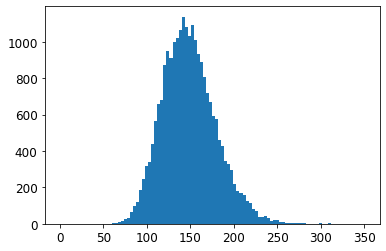

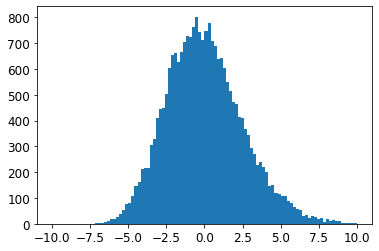

In [75]:
mean_density = np.average(maps['density'], weights=maps['FRACAREA'])
print(mean_density)
plt.hist(maps['density'], 100, range=(0, 350))
plt.show()

plt.hist((maps['density']-mean_density)/np.sqrt(mean_density), 100, range=(-10, 10))
plt.show()

In [84]:
target_densities_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/lrg_xcorr/density_maps/1.0.0/resolve/v0.1'
randoms_counts_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_sys/randoms_stats/0.49.0/resolve/counts'

min_nobs = 2
maskbits = [1, 8, 9, 11, 12, 13]
nside = 64
min_pix_frac = 0.2  # minimum fraction of pixel area to be used

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print(nside, 'Healpix size = {:.5f} sq deg'.format(pix_area))

bin_index = 5
field = 'combined'
density_north = Table.read(os.path.join(target_densities_dir, 'density_map_lrg_pz_bin_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(bin_index, 'north', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
density_south = Table.read(os.path.join(target_densities_dir, 'density_map_lrg_pz_bin_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(bin_index, 'south', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))

mask = (density_north['DEC']>32.375)
density_north = density_north[mask]
mask = ~np.in1d(density_south['HPXPIXEL'], density_north['HPXPIXEL'])
density = vstack([density_north, density_south[mask]])

maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format('north', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
maps = maps[maps['n_randoms']>0]
maps_north = maps.copy()

maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format('south', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
maps = maps[maps['n_randoms']>0]
maps_south = maps.copy()

mask = (maps_north['DEC']>32.375)
maps_north = maps_north[mask]
mask = ~np.in1d(maps_south['HPXPIXEL'], maps_north['HPXPIXEL'])
maps = vstack([maps_north, maps_south[mask]])

maps = join(maps, density[['HPXPIXEL', 'n_targets']], join_type='outer', keys='HPXPIXEL').filled(0)

print(len(maps))

area = np.sum(maps['FRACAREA'])*pix_area
print('Area = {:.1f} sq deg'.format(area))

mask = maps['FRACAREA']>min_pix_frac
maps = maps[mask]

maps['density'] = maps['n_targets'] / (pix_area * maps['FRACAREA'])

64 Healpix size = 0.83929 sq deg
24019
Area = 17506.9 sq deg


120.15436825792864


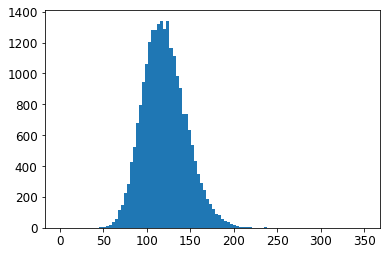

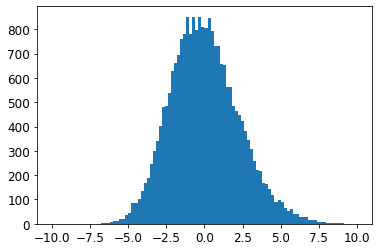

In [85]:
mean_density = np.average(maps['density'], weights=maps['FRACAREA'])
print(mean_density)
plt.hist(maps['density'], 100, range=(0, 350))
plt.show()

plt.hist((maps['density']-mean_density)/np.sqrt(mean_density), 100, range=(-10, 10))
plt.show()

In [91]:
target_densities_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/lrg_xcorr/density_maps/1.0.0/resolve/v0.1'
randoms_counts_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_sys/randoms_stats/0.49.0/resolve/counts'

min_nobs = 2
maskbits = [1, 8, 9, 11, 12, 13]
nside = 64
min_pix_frac = 0.2  # minimum fraction of pixel area to be used

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print(nside, 'Healpix size = {:.5f} sq deg'.format(pix_area))

for bin_index in [1, 2, 3, 4]:
    field = 'combined'
    density_north = Table.read(os.path.join(target_densities_dir, 'density_map_lrg_pz_bin_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(bin_index, 'north', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
    density_south = Table.read(os.path.join(target_densities_dir, 'density_map_lrg_pz_bin_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(bin_index, 'south', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))

    mask = (density_north['DEC']>32.375)
    density_north = density_north[mask]
    mask = ~np.in1d(density_south['HPXPIXEL'], density_north['HPXPIXEL'])
    density = vstack([density_north, density_south[mask]])

    maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format('north', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
    maps = maps[maps['n_randoms']>0]
    maps_north = maps.copy()

    maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format('south', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
    maps = maps[maps['n_randoms']>0]
    maps_south = maps.copy()

    mask = (maps_north['DEC']>32.375)
    maps_north = maps_north[mask]
    mask = ~np.in1d(maps_south['HPXPIXEL'], maps_north['HPXPIXEL'])
    maps = vstack([maps_north, maps_south[mask]])

    maps = join(maps, density[['HPXPIXEL', 'n_targets']], join_type='outer', keys='HPXPIXEL').filled(0)

    print(len(maps))

    area = np.sum(maps['FRACAREA'])*pix_area
    print('Area = {:.1f} sq deg'.format(area))

    mask = maps['FRACAREA']>min_pix_frac
    maps = maps[mask]

    maps['density'] = maps['n_targets'] / (pix_area * maps['FRACAREA'])

    mean_density = np.average(maps['density'], weights=maps['FRACAREA'])
    print(mean_density)
    print(np.median(maps['density']))
    print()

64 Healpix size = 0.83929 sq deg
24019
Area = 17506.9 sq deg
121.1666934545866
118.91256934228768

24019
Area = 17506.9 sq deg
120.23954920639207
117.6959587280347

24019
Area = 17506.9 sq deg
120.78858850525805
118.39935653289635

24019
Area = 17506.9 sq deg
121.04607768952448
118.99116472569925



In [88]:
target_densities_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/lrg_xcorr/density_maps/1.0.0/resolve/v1.0'
randoms_counts_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_sys/randoms_stats/0.49.0/resolve/counts'

min_nobs = 2
maskbits = [1, 8, 9, 11, 12, 13]
nside = 64
min_pix_frac = 0.2  # minimum fraction of pixel area to be used

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print(nside, 'Healpix size = {:.5f} sq deg'.format(pix_area))

for bin_index in [1, 2, 3, 4]:
    field = 'combined'
    density_north = Table.read(os.path.join(target_densities_dir, 'density_map_lrg_pz_bin_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(bin_index, 'north', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
    density_south = Table.read(os.path.join(target_densities_dir, 'density_map_lrg_pz_bin_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(bin_index, 'south', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))

    mask = (density_north['DEC']>32.375)
    density_north = density_north[mask]
    mask = ~np.in1d(density_south['HPXPIXEL'], density_north['HPXPIXEL'])
    density = vstack([density_north, density_south[mask]])

    maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format('north', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
    maps = maps[maps['n_randoms']>0]
    maps_north = maps.copy()

    maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format('south', nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
    maps = maps[maps['n_randoms']>0]
    maps_south = maps.copy()

    mask = (maps_north['DEC']>32.375)
    maps_north = maps_north[mask]
    mask = ~np.in1d(maps_south['HPXPIXEL'], maps_north['HPXPIXEL'])
    maps = vstack([maps_north, maps_south[mask]])

    maps = join(maps, density[['HPXPIXEL', 'n_targets']], join_type='outer', keys='HPXPIXEL').filled(0)

    print(len(maps))

    area = np.sum(maps['FRACAREA'])*pix_area
    print('Area = {:.1f} sq deg'.format(area))

    mask = maps['FRACAREA']>min_pix_frac
    maps = maps[mask]

    maps['density'] = maps['n_targets'] / (pix_area * maps['FRACAREA'])

    mean_density = np.average(maps['density'], weights=maps['FRACAREA'])
    print(mean_density)
    print(np.median(maps['density']))
    print()

64 Healpix size = 0.83929 sq deg
24023
Area = 17506.9 sq deg
83.86110172431944
81.77666358235007

24023
Area = 17506.9 sq deg
149.9384478917197
147.3155462260922

24024
Area = 17506.9 sq deg
162.66286727579174
159.91656148532988

24024
Area = 17506.9 sq deg
148.3904787872848
146.51663613636129



148.3904787872848


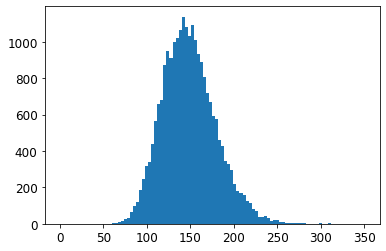

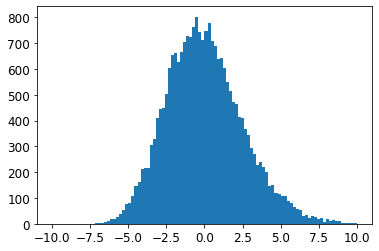

In [75]:
mean_density = np.average(maps['density'], weights=maps['FRACAREA'])
print(mean_density)
plt.hist(maps['density'], 100, range=(0, 350))
plt.show()

plt.hist((maps['density']-mean_density)/np.sqrt(mean_density), 100, range=(-10, 10))
plt.show()

In [89]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/lrg_xcorr/catalogs/main_lrg_minobs_1_maskbits_189111213_20210723.fits'))

In [92]:
cat.colnames

['RA',
 'DEC',
 'NOBS_G',
 'NOBS_R',
 'NOBS_Z',
 'MASKBITS',
 'PHOTSYS',
 'TARGETID',
 'EBV',
 'FLUX_G',
 'FLUX_R',
 'FLUX_Z',
 'MW_TRANSMISSION_G',
 'MW_TRANSMISSION_R',
 'MW_TRANSMISSION_Z',
 'FLUX_W1',
 'MW_TRANSMISSION_W1',
 'FIBERFLUX_Z',
 'Z_PHOT_MEAN',
 'Z_PHOT_MEDIAN',
 'Z_PHOT_STD',
 'Z_PHOT_L68',
 'Z_PHOT_U68',
 'Z_PHOT_L95',
 'Z_PHOT_U95',
 'Z_SPEC',
 'SURVEY',
 'TRAINING',
 'KFOLD',
 'pz_bin']

In [101]:
min_nobs = 2
mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]

In [108]:
area = np.sum(pix_area*maps['FRACAREA'])
mask = maps['DEC']>-20
area1 = np.sum(pix_area*maps['FRACAREA'][mask])
print(area)
print(area1)

17468.694900000002
13856.7184125


In [103]:
t = Table()
t['type'], t['count'] = np.unique(cat['pz_bin'], return_counts=True)
# t.sort('count')
t

type,count
int16,int64
-1,1039509
1,1468413
2,2625190
3,2848301
4,2598568


In [104]:
for bin_index in range(1, 5):
    mask = cat['pz_bin']==bin_index
    print(np.sum(mask)/area)

84.05968553495086
150.27968689292294
163.0517343342003
148.75570355287388


In [105]:
len(cat)/area

605.6537743984526

In [ ]:
np.average(maps['density'], weights=maps['FRACAREA'])